# Лабораторна Робота №3
**Тема:** Сучасні архітектури та Передача навчання (Transfer Learning)

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

from pathlib import Path

import kagglehub

In [2]:
# Створюємо директорію для результатів
output_dir = 'output_lab3'
os.makedirs(output_dir, exist_ok=True)

In [3]:
# Словник для збереження метрик Бенчмарку
benchmark_results = {}

### ЗАВАНТАЖЕННЯ ТА ПІДГОТОВКА ДАНИХ CIFAR-10

In [4]:
(x_train_full, y_train_full), (x_test_full, y_test_full) = cifar10.load_data()
num_classes = 10

class_names = ["airplane", "automobile", "bird", "cat", "deer", 
               "dog", "frog", "horse", "ship", "truck"]

SUBSET_TRAIN = 5000
SUBSET_TEST = 500

x_train_sub = x_train_full[:SUBSET_TRAIN]
y_train_sub = y_train_full[:SUBSET_TRAIN]
x_test_sub = x_test_full[:SUBSET_TEST]
y_test_sub = y_test_full[:SUBSET_TEST]

d:\workspace\uni\Masters\CV\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [5]:
# Функція підготовки (зміна розміру до 224x224 та нормалізація)
def prep(x):
    x = tf.image.resize(x, (224, 224))
    return tf.cast(x, tf.float32) / 255.0

print("Масштабування зображень до 224x224 (це займе трохи часу)...")
x_train = prep(x_train_sub)
x_test = prep(x_test_sub)

y_train = to_categorical(y_train_sub, num_classes)
y_test = to_categorical(y_test_sub, num_classes)

# Аугментація даних
data_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
])

Масштабування зображень до 224x224 (це займе трохи часу)...


In [6]:

# ПРОФЕСІЙНА ФУНКЦІЯ ДЛЯ ОЦІНКИ (Classification Report, Confusion Matrix, Top-10 Errors)
def evaluate_model_comprehensive(model, x_test_data, y_test_data, model_name):
    print(f"\n=== ОЦІНКА МОДЕЛІ {model_name} ===")
    
    probs = model.predict(x_test_data, verbose=0)
    y_pred = np.argmax(probs, axis=1)
    y_true = np.argmax(y_test_data, axis=1)
    
    # 1. Classification Report
    print(f"\nЗвіт класифікації ({model_name}):")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # 2. Матриця плутанини
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8), facecolor='white')
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Прогнозований")
    plt.ylabel("Справжній")
    plt.title(f"Матриця плутанини ({model_name})", fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'{model_name}_confusion_matrix.png'), dpi=150)
    plt.close()
    
    # 3. Топ-10 найвпевненіших помилок
    errors_idx = np.where(y_pred != y_true)[0]
    if len(errors_idx) > 0:
        error_confidences = probs[errors_idx, y_pred[errors_idx]]
        sorted_errors_indices = errors_idx[np.argsort(error_confidences)[::-1]]
        top_10_errors = sorted_errors_indices[:10]

        plt.figure(figsize=(16, 7), facecolor='white')
        plt.suptitle(f"Топ-10 найвпевненіших помилок - {model_name}", fontsize=16, fontweight='bold', y=0.98)
        for i, idx in enumerate(top_10_errors):
            plt.subplot(2, 5, i + 1)
            plt.imshow(np.clip(x_test_data[idx].numpy(), 0, 1)) # .numpy() бо це EagerTensor
            
            pred_label = class_names[y_pred[idx]]
            true_label = class_names[y_true[idx]]
            conf = probs[idx, y_pred[idx]] * 100
            
            color = 'red' if conf > 80 else 'black'
            plt.title(f"Pred: {pred_label} ({conf:.1f}%)\nTrue: {true_label}", fontsize=10, color=color)
            plt.axis('off')

        plt.subplots_adjust(hspace=0.5, top=0.85, bottom=0.05)
        plt.savefig(os.path.join(output_dir, f'{model_name}_top_errors.png'), dpi=150)
        plt.close()
    
    return np.mean(y_pred == y_true)

### 1.1 ResNet50 (Transfer Learning & Fine-Tuning)

In [17]:
keras.backend.clear_session()

base_resnet = keras.applications.ResNet50(include_top=False, weights="imagenet", input_shape=(224,224,3))
base_resnet.trainable = False # Заморожуємо базу

inputs = keras.Input(shape=(224,224,3))
x = data_aug(inputs)
x = keras.applications.resnet.preprocess_input(x)
x = base_resnet(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model_resnet = keras.Model(inputs, outputs)

model_resnet.compile(optimizer=keras.optimizers.Adam(1e-3),
                     loss="categorical_crossentropy", metrics=["accuracy"])

print("Навчання ResNet50 (Transfer Learning - 1 epoch)...")
model_resnet.fit(x_train, y_train, validation_split=0.2, epochs=5, batch_size=32, verbose=1)

# Fine-tuning ResNet50
print("\nFine-tuning ResNet50 (Розморожуємо верхні 50 шарів)...")
base_resnet.trainable = True
for layer in base_resnet.layers[:-50]:
    layer.trainable = False

model_resnet.compile(optimizer=keras.optimizers.Adam(1e-4), # Зменшений LR
                     loss="categorical_crossentropy", metrics=["accuracy"])

model_resnet.fit(x_train, y_train, validation_split=0.2, epochs=5, batch_size=32, verbose=1)

acc_resnet = evaluate_model_comprehensive(model_resnet, x_test, y_test, "ResNet50_FT")
benchmark_results["ResNet50"] = acc_resnet

Навчання ResNet50 (Transfer Learning - 1 epoch)...
Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 230s 2s/step - accuracy: 0.0955 - loss: 2.4246 - val_accuracy: 0.1360 - val_loss: 2.3129
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 219s 2s/step - accuracy: 0.1125 - loss: 2.3448 - val_accuracy: 0.1000 - val_loss: 2.2915
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 222s 2s/step - accuracy: 0.1150 - loss: 2.3263 - val_accuracy: 0.1140 - val_loss: 2.2918
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 218s 2s/step - accuracy: 0.1128 - loss: 2.3087 - val_accuracy: 0.1020 - val_loss: 2.2836
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 216s 2s/step - accuracy: 0.1227 - loss: 2.3009 - val_accuracy: 0.1460 - val_loss: 2.2915

Fine-tuning ResNet50 (Розморожуємо верхні 50 шарів)...
Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 353s 3s/step - accuracy: 0.2390 - loss: 2.1060 - val_accuracy: 0.1510 - val_loss: 2.6287
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 339s 3s/step - accuracy: 0.3047 - loss: 1.8796 - val_accuracy: 0.1180 - val_loss: 6.30

d:\workspace\uni\Masters\CV\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\workspace\uni\Masters\CV\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\workspace\uni\Masters\CV\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### 1.2 MobileNetV3Large (Transfer Learning & Fine-Tuning)

In [18]:
keras.backend.clear_session()

base_mobile = keras.applications.MobileNetV3Large(include_top=False, weights="imagenet", input_shape=(224,224,3))
base_mobile.trainable = False

inputs = keras.Input(shape=(224,224,3))
x = data_aug(inputs)
x = keras.applications.mobilenet_v3.preprocess_input(x)
x = base_mobile(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model_mobile = keras.Model(inputs, outputs)
model_mobile.compile(optimizer=keras.optimizers.Adam(1e-3),
                     loss="categorical_crossentropy", metrics=["accuracy"])

print("Навчання MobileNetV3 (Transfer Learning - 1 epoch)...")
model_mobile.fit(x_train, y_train, validation_split=0.2, epochs=5, batch_size=32, verbose=1)

# Fine-tuning MobileNetV3
print("\nFine-tuning MobileNetV3 (Розморожуємо верхні 40 шарів)...")
base_mobile.trainable = True
for layer in base_mobile.layers[:-40]:
    layer.trainable = False

model_mobile.compile(optimizer=keras.optimizers.Adam(1e-4),
                     loss="categorical_crossentropy", metrics=["accuracy"])

model_mobile.fit(x_train, y_train, validation_split=0.2, epochs=5, batch_size=32, verbose=1)

# ЗБЕРЕЖЕННЯ ДЛЯ ЕТАПУ КВАНТИЗАЦІЇ (Завдання 1.2.4)
model_mobile.save(os.path.join(output_dir, "mobilenet_v3_ft.keras"))

acc_mobile = evaluate_model_comprehensive(model_mobile, x_test, y_test, "MobileNetV3_FT")
benchmark_results["MobileNetV3"] = acc_mobile

Навчання MobileNetV3 (Transfer Learning - 1 epoch)...
Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 79s 597ms/step - accuracy: 0.0978 - loss: 2.3693 - val_accuracy: 0.1620 - val_loss: 2.3052
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 74s 596ms/step - accuracy: 0.1030 - loss: 2.3263 - val_accuracy: 0.1040 - val_loss: 2.3023
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 74s 590ms/step - accuracy: 0.1025 - loss: 2.3167 - val_accuracy: 0.1000 - val_loss: 2.3025
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 74s 592ms/step - accuracy: 0.1147 - loss: 2.3067 - val_accuracy: 0.1480 - val_loss: 2.2905
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 73s 588ms/step - accuracy: 0.1147 - loss: 2.3023 - val_accuracy: 0.1450 - val_loss: 2.2918

Fine-tuning MobileNetV3 (Розморожуємо верхні 40 шарів)...
Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 101s 750ms/step - accuracy: 0.2407 - loss: 2.0651 - val_accuracy: 0.0960 - val_loss: 2.3160
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 93s 741ms/step - accuracy: 0.3627 - loss: 1.7640 - val_accuracy: 0.

d:\workspace\uni\Masters\CV\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\workspace\uni\Masters\CV\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\workspace\uni\Masters\CV\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### 1.3 EfficientNetB0 (Transfer Learning & Fine-Tuning)

In [19]:
keras.backend.clear_session()

base_eff = keras.applications.EfficientNetB0(include_top=False, weights="imagenet", input_shape=(224,224,3))
base_eff.trainable = False

inputs = keras.Input(shape=(224,224,3))
x = data_aug(inputs)
x = keras.applications.efficientnet.preprocess_input(x)
x = base_eff(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model_eff = keras.Model(inputs, outputs)
model_eff.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="categorical_crossentropy", metrics=["accuracy"])

print("Навчання EfficientNetB0 (Transfer Learning - 1 epoch)...")
model_eff.fit(x_train, y_train, validation_split=0.2, epochs=5, batch_size=32, verbose=1)

# Fine-tuning EfficientNetB0
print("\nFine-tuning EfficientNetB0 (Розморожуємо верхні 40 шарів)...")
base_eff.trainable = True
for layer in base_eff.layers[:-40]:
    layer.trainable = False

model_eff.compile(optimizer=keras.optimizers.Adam(1e-4),
                  loss="categorical_crossentropy", metrics=["accuracy"])

model_eff.fit(x_train, y_train, validation_split=0.2, epochs=5, batch_size=32, verbose=1)

acc_eff = evaluate_model_comprehensive(model_eff, x_test, y_test, "EfficientNetB0_FT")
benchmark_results["EfficientNetB0"] = acc_eff

Навчання EfficientNetB0 (Transfer Learning - 1 epoch)...
Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 122s 916ms/step - accuracy: 0.1045 - loss: 2.3363 - val_accuracy: 0.0990 - val_loss: 2.3608
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 115s 921ms/step - accuracy: 0.0962 - loss: 2.3389 - val_accuracy: 0.1090 - val_loss: 2.3166
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 112s 897ms/step - accuracy: 0.0990 - loss: 2.3430 - val_accuracy: 0.1010 - val_loss: 2.3133
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 114s 909ms/step - accuracy: 0.1005 - loss: 2.3382 - val_accuracy: 0.0950 - val_loss: 2.3265
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 114s 912ms/step - accuracy: 0.1053 - loss: 2.3339 - val_accuracy: 0.1050 - val_loss: 2.3343

Fine-tuning EfficientNetB0 (Розморожуємо верхні 40 шарів)...
Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.0972 - loss: 2.3436 - val_accuracy: 0.0990 - val_loss: 2.3351
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.0990 - loss: 2.3291 - val_accura

d:\workspace\uni\Masters\CV\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\workspace\uni\Masters\CV\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\workspace\uni\Masters\CV\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### 1.4 ФІНАЛЬНИЙ БЕНЧМАРК АРХІТЕКТУР

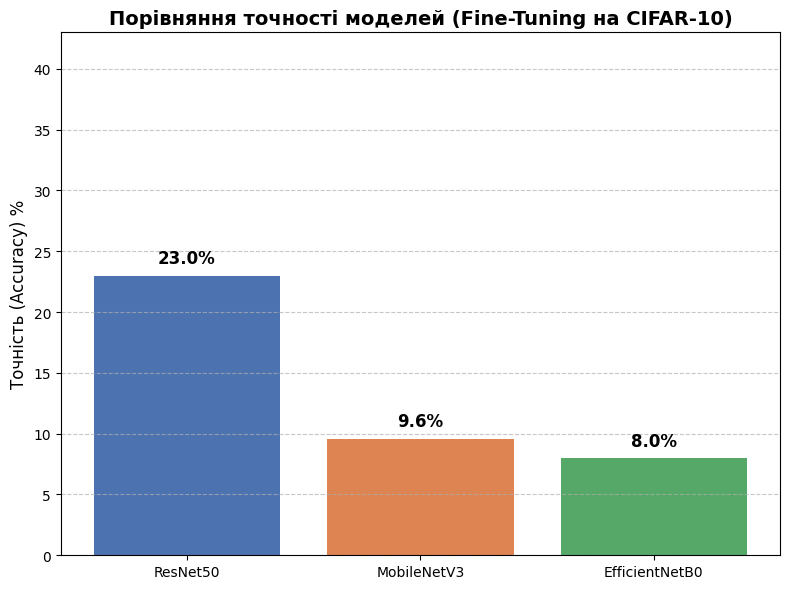

In [20]:
models_names = list(benchmark_results.keys())
accuracies = [benchmark_results[n] * 100 for n in models_names]
colors = ['#4C72B0', '#DD8452', '#55A868']

plt.figure(figsize=(8, 6), facecolor='white')
bars = plt.bar(models_names, accuracies, color=colors)
plt.title('Порівняння точності моделей (Fine-Tuning на CIFAR-10)', fontsize=14, fontweight='bold')
plt.ylabel('Точність (Accuracy) %', fontsize=12)
plt.ylim(0, max(accuracies) + 20) # Трохи запасу зверху
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f"{acc:.1f}%", ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'benchmark_3_models.png'), dpi=150)
plt.show()

### 1.2.4 Експорт у TensorFlow Lite (TFLite) та Квантизація

In [22]:
model_path = os.path.join(output_dir, "mobilenet_v3_ft.keras")
model = keras.models.load_model(model_path)
print("Навчену модель MobileNetV3 успішно завантажено.")

# Завантажуємо 200 тестових зображень для калібрування INT8
(_, _), (x_test_full, _) = cifar10.load_data()

Навчену модель MobileNetV3 успішно завантажено.


d:\workspace\uni\Masters\CV\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [23]:
def prep_for_model(x):
    x = tf.image.resize(x, (224, 224))
    return (tf.cast(x, tf.float32) / 255.0).numpy()

x_calib = prep_for_model(x_test_full[:200])

In [33]:
def representative_data_gen():
    for i in range(len(x_calib)):
        yield [np.expand_dims(x_calib[i], axis=0).astype(np.float32)]
conversion_times = {}

In [25]:
# 1. Базовий FP32 (Без квантизації)
t0 = time.time()
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_fp32 = converter.convert()
with open(os.path.join(output_dir, "model_fp32.tflite"), "wb") as f:
    f.write(tflite_fp32)
conversion_times["FP32"] = time.time() - t0
print("1/4: Базова конверсія FP32 завершена.")

INFO:tensorflow:Assets written to: C:\Users\mfese\AppData\Local\Temp\tmp6g6lcxt9\assets


INFO:tensorflow:Assets written to: C:\Users\mfese\AppData\Local\Temp\tmp6g6lcxt9\assets


Saved artifact at 'C:\Users\mfese\AppData\Local\Temp\tmp6g6lcxt9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2226885200976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885203280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885199440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885198288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885199248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885202896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885200784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885203472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885198480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885207312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  222

In [26]:
# 2. Квантування динамічного діапазону (Dynamic Range)
t0 = time.time()
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_dynamic = converter.convert()
with open(os.path.join(output_dir, "model_dynamic.tflite"), "wb") as f:
    f.write(tflite_dynamic)
conversion_times["Dynamic"] = time.time() - t0
print("2/4: Динамічна квантизація завершена.")

INFO:tensorflow:Assets written to: C:\Users\mfese\AppData\Local\Temp\tmpd4ndyfl3\assets


INFO:tensorflow:Assets written to: C:\Users\mfese\AppData\Local\Temp\tmpd4ndyfl3\assets


Saved artifact at 'C:\Users\mfese\AppData\Local\Temp\tmpd4ndyfl3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2226885200976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885203280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885199440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885198288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885199248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885202896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885200784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885203472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885198480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885207312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  222

In [27]:
# 3. Квантизація із Float16
t0 = time.time()
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_f16 = converter.convert()
with open(os.path.join(output_dir, "model_f16.tflite"), "wb") as f:
    f.write(tflite_f16)
conversion_times["Float16"] = time.time() - t0
print("3/4: Float16 квантизація завершена.")


INFO:tensorflow:Assets written to: C:\Users\mfese\AppData\Local\Temp\tmp4j_c_s2y\assets


INFO:tensorflow:Assets written to: C:\Users\mfese\AppData\Local\Temp\tmp4j_c_s2y\assets


Saved artifact at 'C:\Users\mfese\AppData\Local\Temp\tmp4j_c_s2y'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2226885200976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885203280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885199440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885198288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885199248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885202896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885200784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885203472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885198480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885207312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  222

In [28]:
# 4. Повна INT8 квантизація
t0 = time.time()
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
tflite_int8 = converter.convert()
with open(os.path.join(output_dir, "model_int8.tflite"), "wb") as f:
    f.write(tflite_int8)
conversion_times["INT8"] = time.time() - t0
print("4/4: Повна INT8 квантизація завершена.")

INFO:tensorflow:Assets written to: C:\Users\mfese\AppData\Local\Temp\tmp_p3c971a\assets


INFO:tensorflow:Assets written to: C:\Users\mfese\AppData\Local\Temp\tmp_p3c971a\assets


Saved artifact at 'C:\Users\mfese\AppData\Local\Temp\tmp_p3c971a'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2226885200976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885203280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885199440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885198288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885199248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885202896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885200784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885203472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885198480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2226885207312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  222

d:\workspace\uni\Masters\CV\.venv\Lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


4/4: Повна INT8 квантизація завершена.


In [29]:
def get_size_mb(filename):
    path = os.path.join(output_dir, filename)
    return os.path.getsize(path) / (1024 * 1024)

sizes = {
    "FP32": get_size_mb("model_fp32.tflite"),
    "Dynamic": get_size_mb("model_dynamic.tflite"),
    "Float16": get_size_mb("model_f16.tflite"),
    "INT8": get_size_mb("model_int8.tflite")
}

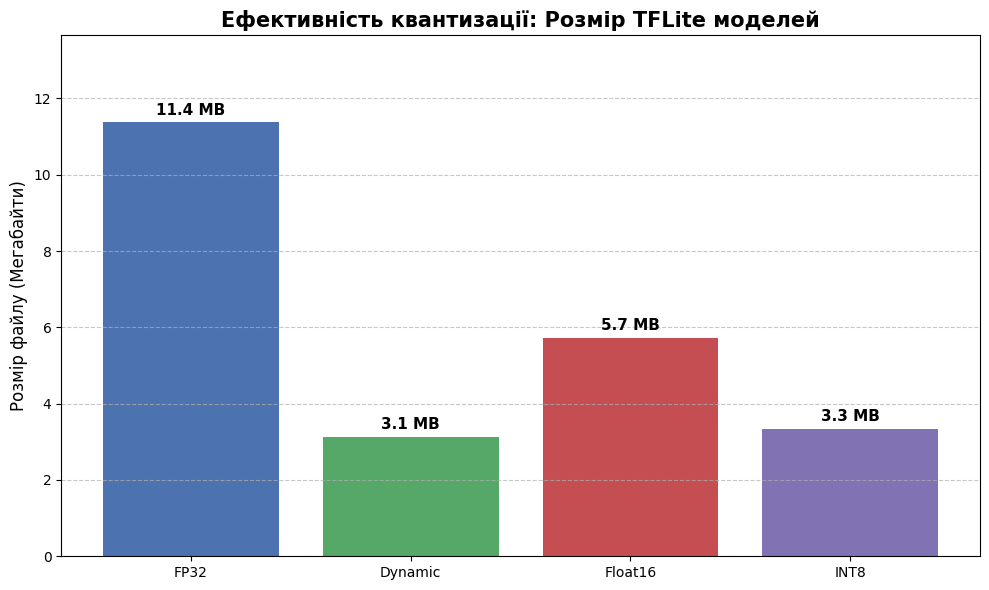

In [30]:
plt.figure(figsize=(10, 6), facecolor='white')
names = list(sizes.keys())
values = list(sizes.values())
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B3']

bars = plt.bar(names, values, color=colors)
plt.title('Ефективність квантизації: Розмір TFLite моделей', fontsize=15, fontweight='bold')
plt.ylabel('Розмір файлу (Мегабайти)', fontsize=12)
plt.ylim(0, max(values) + max(values)*0.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, 
             f"{val:.1f} MB", ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'tflite_quantization_sizes.png'), dpi=150)
plt.show()

In [32]:
print("\nЧас витрачений на конверсію:")
for name, t in conversion_times.items():
    print(f"- {name}: {t:.2f} секунд")


Час витрачений на конверсію:
- FP32: 13.81 секунд
- Dynamic: 9.14 секунд
- Float16: 10.03 секунд
- INT8: 25.11 секунд


## 2. Точне налаштування на власному наборі (Класифікація фруктів)

In [7]:
# 1) Налаштовуємо кеш на D:
CACHE_DIR = r"D:\kagglehub_cache"
os.makedirs(CACHE_DIR, exist_ok=True)
os.environ["KAGGLEHUB_CACHE"] = CACHE_DIR
import kagglehub

output_dir = 'output_lab3'
os.makedirs(output_dir, exist_ok=True)

print("=== ПЕРЕВІРКА ДАТАСЕТУ ФРУКТІВ З KAGGLE ===")
dataset_path = kagglehub.dataset_download("moltean/fruits")

base_fruits_dir = None
for root, dirs, files in os.walk(dataset_path):
    if "Training" in dirs and "Validation" in dirs and "Test" in dirs:
        base_fruits_dir = Path(root)
        if "original" in str(root).lower():
            break 

if base_fruits_dir is None:
    raise FileNotFoundError(f"Не знайдено папки Training/Validation/Test у {dataset_path}")

train_dir = str(base_fruits_dir / "Training")
val_dir = str(base_fruits_dir / "Validation")
test_dir = str(base_fruits_dir / "Test")

print("Знайдено правильну директорію:", base_fruits_dir)

=== ПЕРЕВІРКА ДАТАСЕТУ ФРУКТІВ З KAGGLE ===
Знайдено правильну директорію: D:\kagglehub_cache\datasets\moltean\fruits\versions\86\fruits-360_original-size\fruits-360-original-size


In [8]:
print("\n=== ПІДГОТОВКА ДАНИХ (БЕЗ ПЕРЕВАНТАЖЕННЯ ПАМ'ЯТІ) ===")
IMG_SIZE = (224, 224)
BATCH = 16
SEED = 42

train_ds = keras.preprocessing.image_dataset_from_directory(
    train_dir, image_size=IMG_SIZE, batch_size=BATCH, seed=SEED)

val_ds = keras.preprocessing.image_dataset_from_directory(
    val_dir, image_size=IMG_SIZE, batch_size=BATCH, seed=SEED)

test_ds = keras.preprocessing.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=BATCH, shuffle=False)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"\nЗнайдено {num_classes} класів фруктів.")

AUTOTUNE = tf.data.AUTOTUNE


=== ПІДГОТОВКА ДАНИХ (БЕЗ ПЕРЕВАНТАЖЕННЯ ПАМ'ЯТІ) ===
Found 49277 files belonging to 139 classes.
Found 24645 files belonging to 139 classes.
Found 24496 files belonging to 139 classes.

Знайдено 139 класів фруктів.


In [9]:
def prep_dataset(ds, training=False):
    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y), num_parallel_calls=AUTOTUNE)
    if training:
        aug = keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.05),
            layers.RandomZoom(0.10),
        ])
        ds = ds.map(lambda x, y: (aug(x, training=True), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_ds = prep_dataset(train_ds, training=True)
val_ds = prep_dataset(val_ds, training=False)
test_ds = prep_dataset(test_ds, training=False)

In [10]:
print("\n=== ПОБУДОВА EfficientNetB0 ДЛЯ ФРУКТІВ ===")
keras.backend.clear_session()

base_model = keras.applications.EfficientNetB0(
    include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,)
)
base_model.trainable = False 

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = keras.applications.efficientnet.preprocess_input(inputs) 
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

cbs_tl = [
    keras.callbacks.ModelCheckpoint(os.path.join(output_dir, "fruits_effb0_tl.keras"), 
                                    save_best_only=True, monitor="val_accuracy"),
    keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True, monitor="val_accuracy")
]

print("Навчання (Transfer Learning) - 1 Епоха...")
# ОБМЕЖУЄМО steps_per_epoch, ЩОБ ЕПОХА ЙШЛА 2 ХВИЛИНИ, А НЕ ГОДИНУ
hist_tl = model.fit(train_ds, validation_data=val_ds, epochs=1, 
                    steps_per_epoch=200, validation_steps=50, 
                    callbacks=cbs_tl, verbose=1)

print("\n=== ТОЧНЕ НАЛАШТУВАННЯ (Fine-Tuning) ===")
base_model.trainable = True
N = 40
for layer in base_model.layers[:-N]:
    layer.trainable = False

model.compile(optimizer=keras.optimizers.Adam(1e-4), 
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

cbs_ft = [
    keras.callbacks.ModelCheckpoint(os.path.join(output_dir, "fruits_effb0_ft.keras"), 
                                    save_best_only=True, monitor="val_accuracy"),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor="val_accuracy")
]


=== ПОБУДОВА EfficientNetB0 ДЛЯ ФРУКТІВ ===

Навчання (Transfer Learning) - 1 Епоха...
200/200 ━━━━━━━━━━━━━━━━━━━━ 129s 573ms/step - accuracy: 0.0109 - loss: 4.9718 - val_accuracy: 0.0063 - val_loss: 4.9909

=== ТОЧНЕ НАЛАШТУВАННЯ (Fine-Tuning) ===


Донавчання (Fine-tuning) - 1 Епоха...
200/200 ━━━━━━━━━━━━━━━━━━━━ 132s 600ms/step - accuracy: 0.0091 - loss: 4.9210 - val_accuracy: 0.0050 - val_loss: 5.0149 - learning_rate: 1.0000e-04

Фінальна точність на тестових даних фруктів (підвибірка): 0.0000

=== ОЦІНКА ЯКОСТІ ТА ВІЗУАЛІЗАЦІЯ ПОМИЛОК ===

=== Звіт класифікації (Фрукти) ===
                        precision    recall  f1-score   support

             Almonds 1     0.0000    0.0000    0.0000      77.0
              Apple 10     0.0000    0.0000    0.0000     231.0
              Apple 11     0.0000    0.0000    0.0000     142.0
              Apple 12     0.0000    0.0000    0.0000     154.0
              Apple 13     0.0000    0.0000    0.0000     196.0

             micro avg     0.0000    0.0000    0.0000     800.0
             macro avg     0.0000    0.0000    0.0000     800.0
          weighted avg     0.0000    0.0000    0.0000     800.0



d:\workspace\uni\Masters\CV\.venv\Lib\site-packages\sklearn\metrics\_classification.py:3091: UserWarning: labels size, 5, does not match size of target_names, 139
  warnings.warn(
d:\workspace\uni\Masters\CV\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\workspace\uni\Masters\CV\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\workspace\uni\Masters\CV\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0

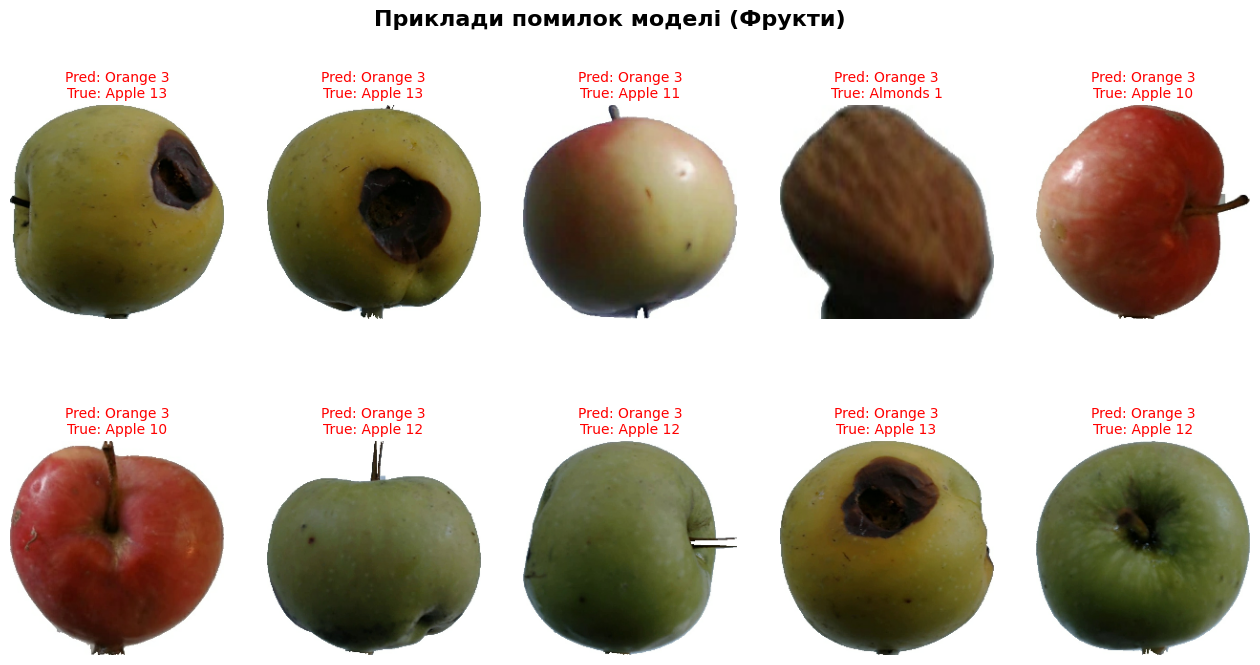

In [11]:
print("Донавчання (Fine-tuning) - 1 Епоха...")
hist_ft = model.fit(train_ds, validation_data=val_ds, epochs=1, 
                    steps_per_epoch=200, validation_steps=50, 
                    callbacks=cbs_ft, verbose=1)

test_loss, test_acc = model.evaluate(test_ds, steps=50, verbose=0)
print(f"\nФінальна точність на тестових даних фруктів (підвибірка): {test_acc:.4f}")

print("\n=== ОЦІНКА ЯКОСТІ ТА ВІЗУАЛІЗАЦІЯ ПОМИЛОК ===")
# Беремо частину тестових даних для швидкої оцінки (50 батчів)
test_ds_sub = test_ds.take(50)
probs = model.predict(test_ds_sub, verbose=0)
y_pred = probs.argmax(axis=1)
y_true = np.concatenate([y.numpy() for x, y in test_ds_sub])

print("\n=== Звіт класифікації (Фрукти) ===")
print(classification_report(y_true, y_pred, target_names=class_names, labels=np.unique(y_true), digits=4))

# Візуалізація помилок
wrong_idx = np.where(y_pred != y_true)[0]
k = min(10, len(wrong_idx))

if k > 0:
    x_test_imgs = np.concatenate([x.numpy() for x, y in test_ds_sub])
    sel = np.random.choice(wrong_idx, size=k, replace=False)
    
    plt.figure(figsize=(16, 7), facecolor='white')
    for i, idx in enumerate(sel, 1):
        plt.subplot(2, 5, i)
        plt.imshow(np.clip(x_test_imgs[idx], 0, 1))
        
        pred_text = class_names[y_pred[idx]]
        true_text = class_names[y_true[idx]]
        
        plt.title(f"Pred: {pred_text[:15]}\nTrue: {true_text[:15]}", fontsize=10, color='red')
        plt.axis("off")
        
    plt.subplots_adjust(hspace=0.5, top=0.85, bottom=0.05)
    plt.suptitle("Приклади помилок моделі (Фрукти)", fontsize=16, fontweight='bold', y=0.98)
    plt.savefig(os.path.join(output_dir, 'fruits_errors.png'), dpi=150)
    plt.show()
else:
    print("Помилкових прикладів = 0! Чудовий результат.")